In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from tqdm import tqdm
import seaborn as sns
import os
import sys
from collections import Counter
import numpy as np
current_dir = os.getcwd()
parent_parent_dir = os.path.dirname(os.path.dirname(current_dir))
src_dir = os.path.join(parent_parent_dir, 'src')
sys.path.append(src_dir)

from util import *

In [2]:
df = pd.read_csv("../../data/processed/surechembl/molecular_descriptors_with_date.csv")

In [3]:
df.head()

,SMILES,DATE,MolecularWeight,TPSA,LogP,YYMMDD
0,Oc1c2ccccc2cc2cc3c(cc12)CC=CC3,1962.082,246.309,20.23,4.3534,19620130
1,C1=CNc2ccccc2C(c2ccccn2)=N1,1963.616,221.263,37.28,2.8157,19630813
2,C1=NC=C(c2cccnc2)Nc2ccccc21,1963.616,221.263,37.28,2.9246,19630813
3,C[C@@H]1CC[C@@]2(OC1)O[C@H]1C[C@H]3[C@@H]4CCC5...,1965.129,416.646,38.69,5.7938,19650216
4,C[C@@H]1CC[C@@]2(OC1)O[C@H]1C[C@H]3[C@@H]4CC[C...,1965.129,416.646,38.69,5.7938,19650216


In [4]:
df_clean = df.dropna(subset=['DATE', 'SMILES', 'MolecularWeight', 'LogP', 'TPSA']).copy()
df_clean = df_clean.sort_values('DATE')
bins =[1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, float('inf')]
labels = [
    '1965-1969', '1970-1974', '1975-1979',
    '1980-1984', '1985-1989', '1990-1994', 
    '1995-1999', '2000-2004', '2005-2009', 
    '2010-2014', '2015-2019', '2020-2024'
]
df_clean['PERIOD'] = pd.cut(
    df_clean['DATE'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

/tmp/ipykernel_1540739/4213944189.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PERIOD', y=prop, data=df_clean, ax=ax, palette="Blues", showfliers=False)
/tmp/ipykernel_1540739/4213944189.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = df_clean.groupby('PERIOD', sort=False)[prop].median()
/tmp/ipykernel_1540739/4213944189.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PERIOD', y=prop, data=df_clean, ax=ax, palette="Blues", showfliers=False)
/tmp/ipykernel_1540739/4213944

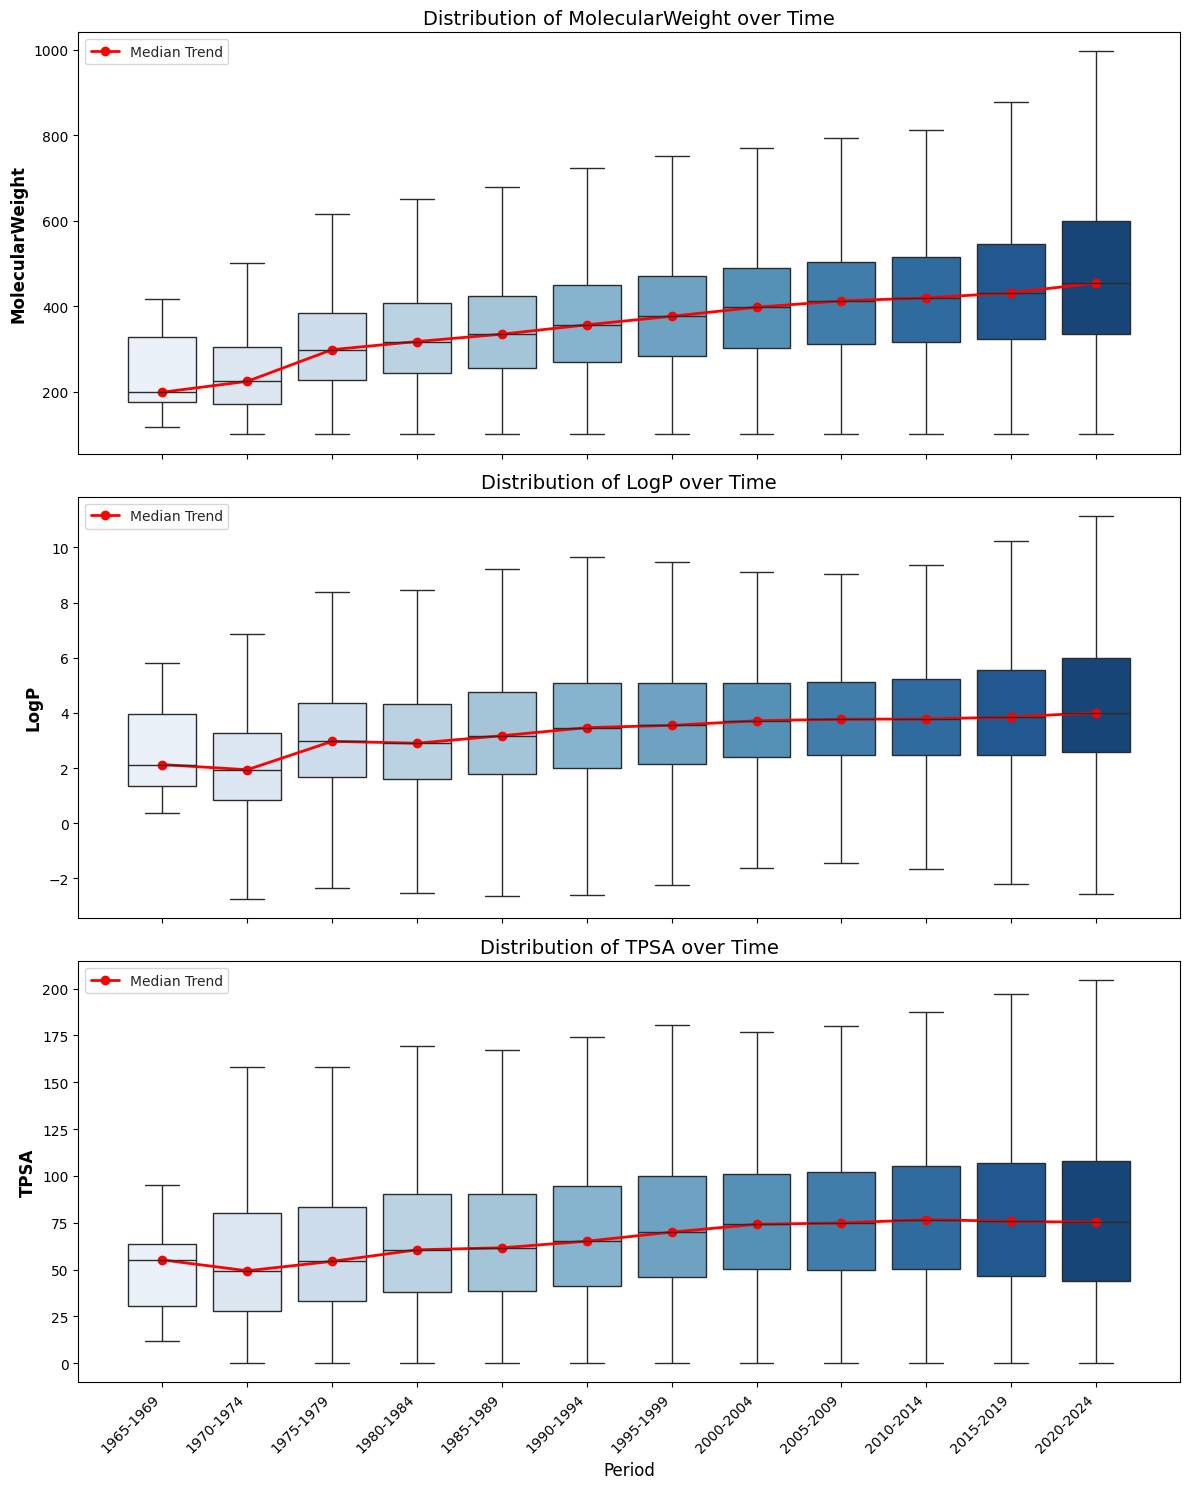

In [5]:
properties = ['MolecularWeight', 'LogP', 'TPSA']

fig, axes = plt.subplots(len(properties), 1, figsize=(12, 5 * len(properties)), sharex=True)
sns.set_style("whitegrid")

for i, prop in enumerate(properties):
    ax = axes[i]
    sns.boxplot(x='PERIOD', y=prop, data=df_clean, ax=ax, palette="Blues", showfliers=False)
    medians = df_clean.groupby('PERIOD', sort=False)[prop].median()
    ax.plot(range(len(medians)), medians.values, color='red', marker='o', linewidth=2, label='Median Trend')
    
    ax.set_ylabel(prop, fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {prop} over Time', fontsize=14)
    ax.legend(loc='upper left')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel('Period', fontsize=12)
plt.tight_layout()
plt.show()